<a href="https://colab.research.google.com/github/Saksham-Mishra1210/Sketch-to-arm/blob/main/Ivlabs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)

4.14.0


In [15]:
from google.colab import files
uploaded= files.upload()


Saving IMG_0055.jpeg to IMG_0055.jpeg


In [16]:
print(uploaded.keys())

dict_keys(['IMG_0055.jpeg'])


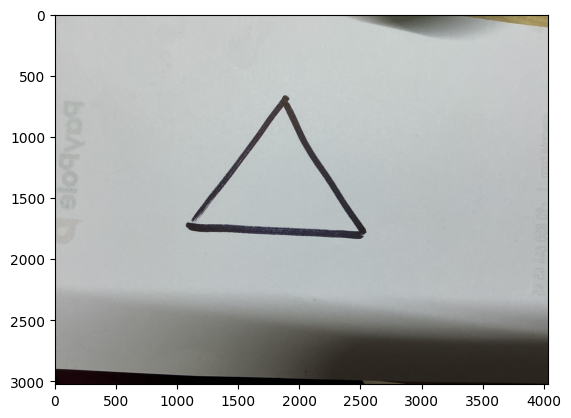

In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('IMG_0055.jpeg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

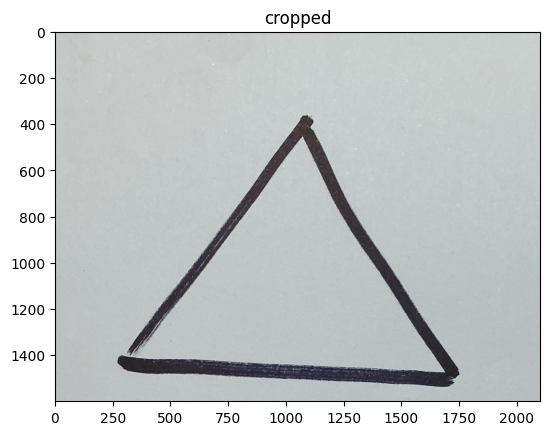

In [18]:
img_cropped=img[300:1900, 800:2900]
img_rgb_cropped=cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb_cropped)
plt.title("cropped")
plt.show()

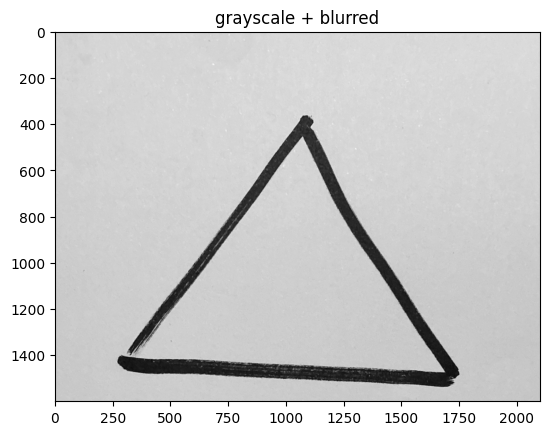

In [19]:
gray=cv2.cvtColor(img_cropped,cv2.COLOR_BGR2GRAY)
blurred=cv2.GaussianBlur(gray, (5,5),0)
plt.imshow(blurred, cmap='gray')
plt.title("grayscale + blurred")
plt.show()

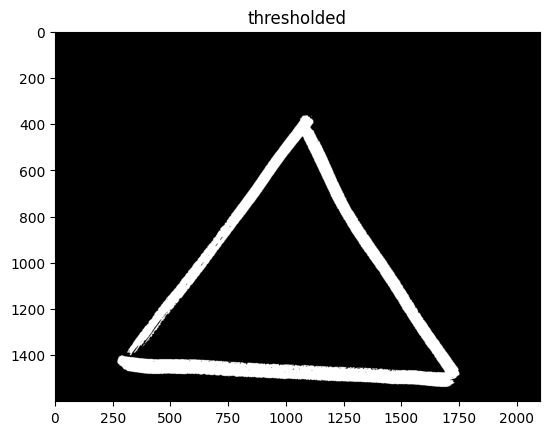

In [20]:
_, thresh=cv2.threshold(blurred, 0, 255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh,cmap='gray')
plt.title("thresholded")
plt.show()

no of contours found =  9
points in largest contour =  3949


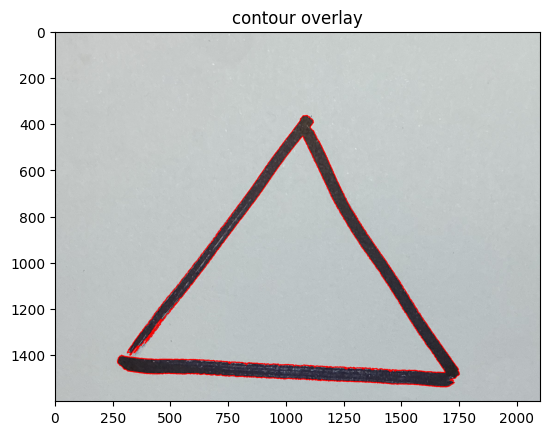

In [21]:
contours, _= cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest=max(contours, key=cv2.contourArea)
print("no of contours found = ", len(contours))
print("points in largest contour = ", len(largest))
img_with_contour=cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB).copy()
cv2.drawContours(img_with_contour, [largest], -1, (255, 0,0), 3)
plt.imshow(img_with_contour)
plt.title("contour overlay")
plt.show()

In [22]:
points = largest.reshape(-1,2)
print("shape of points array: ", points.shape)
print("first 5 points:\n", points[:5])

shape of points array:  (3949, 2)
first 5 points:
 [[1082  365]
 [1081  366]
 [1071  366]
 [1070  367]
 [1070  368]]


In [29]:
from matplotlib.colors import CenteredNorm
def scale_to_workspace(points,workspace_size=1.5):
  points=points.astype(float)
  centroid=points.mean(axis=0)
  centered=points-centroid
  max_dist=np.max(np.linalg.norm(centered,axis=1))
  scaled=centered/max_dist * workspace_size
  return scaled

workspace_points=scale_to_workspace(points)

In [23]:
import numpy as np
def fk(theta1,theta2,l1,l2):
       x=l1*np.cos(theta1) + l2*np.cos(theta1+theta2)
       y=l1*np.sin(theta1)+ l2*np.sin(theta1+theta2)
       return x,y


In [24]:
import numpy as np
def ik(x,y,l1,l2):
  theta2=np.arccos((x**2+y**2-l1**2-l2**2)/2*l1*l2)
  k1=l1+l2*np.cos(theta2)
  k2= l2*np.sin(theta2)
  theta1=np.atan2(y,x)-np.atan2(k2,k1)
  return theta1,theta2


In [25]:
test_points=[(1.0,1.0),(1.5,0.5),(0.5,1.2)]
for x,y in test_points:
  theta1,theta2=ik(x,y,1.0,1.0)
  x_check,y_check=fk(theta1,theta2,1.0,1.0)
  print("angles are:", theta1,theta2)
  print("fk values are: ", x_check,y_check)

angles are: 0.0 1.5707963267948966
fk values are:  1.0 1.0
angles are: -0.3373074814297668 1.318116071652818
fk values are:  1.5 0.5
angles are: 0.312793317025594 1.726423780139082
fk values are:  0.5 1.2


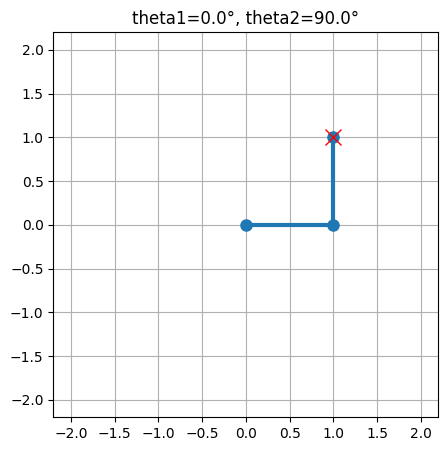

In [26]:
import matplotlib.pyplot as plt

def plot_arm(theta1, theta2, l1=1.0, l2=1.0, target=None):
    elbow_x = l1 * np.cos(theta1)
    elbow_y = l1 * np.sin(theta1)
    tip_x, tip_y = fk(theta1, theta2, l1, l2)

    plt.figure(figsize=(5,5))
    plt.plot([0, elbow_x, tip_x], [0, elbow_y, tip_y], 'o-', linewidth=3, markersize=8)
    if target:
        plt.plot(target[0], target[1], 'rx', markersize=12)
    plt.xlim(-2.2, 2.2)
    plt.ylim(-2.2, 2.2)
    plt.grid(True)
    plt.gca().set_aspect('equal')
    plt.title(f"theta1={np.degrees(theta1):.1f}°, theta2={np.degrees(theta2):.1f}°")
    plt.show()

# Test it
theta1, theta2 = ik(1.0, 1.0, 1.0, 1.0)
plot_arm(theta1, theta2, target=(1.0, 1.0))

In [38]:
def path_to_angles(points,l1=1.0,l2=1.0):
  angles = []
  skipped=0
  for x,y in points:
    cos_theta2=(x**2+y**2-l1**2-l2**2)/2*l1*l2
    if cos_theta2<-1 or cos_theta2>1:
      skipped+=1
      continue
    theta1,theta2=ik(x,y,l1,l2)
    angles.append((theta1,theta2))
  print("number of angle pairs: ", len(angles))
  print("number of points skipped: ", skipped)
  return angles
angle_path=path_to_angles(workspace_points)

number of angle pairs:  3949
number of points skipped:  0


In [32]:
print(workspace_points.shape)

(3949, 2)


In [34]:
print(len(workspace_points))
angle_path= path_to_angles(workspace_points)

3949
number of angle pairs:  1
number of points skipped:  0


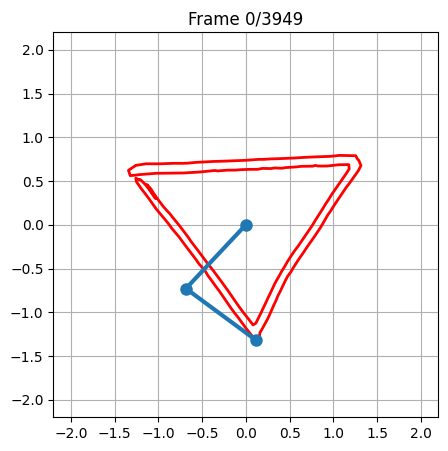

In [42]:
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5,5))
traced_x=[]
traced_y=[]
def update(frame):
    ax.clear()
    theta1, theta2 = angle_path[frame]
    elbow_x = np.cos(theta1)
    elbow_y = np.sin(theta1)
    tip_x, tip_y = fk(theta1, theta2,l1=1.0,l2=1.0)

    traced_x.append(tip_x)
    traced_y.append(tip_y)

    ax.plot(traced_x, traced_y, 'r-', linewidth=2)
    ax.plot([0, elbow_x, tip_x], [0, elbow_y, tip_y], 'o-', linewidth=3, markersize=8)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.set_title(f"Frame {frame}/{len(angle_path)}")

step = 20
frames_to_use = range(0, len(angle_path), step)

ani = animation.FuncAnimation(fig, update, frames=frames_to_use, interval=50)
HTML(ani.to_jshtml())